# Práctica Distribuciones Power Law <img src="http://www.ubu.es/sites/default/files/portal_page/images/logo_color_2l_dcha.jpg" height="75" align="right"/>

## Autores
> Roberto Iturralde Zarzo <br/>
> Rubén Castañeda Matute

## Introducción

En esta práctica vamos a estudiar la red de routers de Internet capturada el 22 de julio de 2006. La idea es sencilla: queremos comprobar si esta red se comporta como una red **libre de escala** (*scale-free*), es decir, si la probabilidad de que un nodo tenga grado $k$ sigue una **ley de potencias** del tipo $p_k \sim k^{-\alpha}$.

Para ello vamos a:

1. Calcular las estadísticas básicas de la red.
2. Dibujar el histograma de la distribución de grado con clases de tamaño constante.
3. Repetirlo con clases de tamaño logarítmico, que es la técnica habitual para reducir el ruido en la cola de la distribución.
4. Estimar el parámetro $\alpha$ ajustando una regresión lineal sobre los datos en escala log-log.
5. Estimar $\alpha$ de nuevo, esta vez a partir de la **distribución acumulada** (que es más estable y por tanto más fiable).

Empezamos importando las librerías que vamos a necesitar a lo largo del notebook.

In [3]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## Carga de la red

El fichero está en formato GEXF, así que usamos directamente la función de NetworkX para leerlo.

In [4]:
G = nx.read_gexf('dataset/internet_routers-22july06-2.gexf')
print(f'¿La red es dirigida? {G.is_directed()}')

¿La red es dirigida? False


## 3.1 Estadísticas básicas

Vamos a calcular las cifras que nos van a dar una primera idea del tamaño y la forma de la red: cuántos nodos hay, cuántos enlaces, y cómo se reparten los grados.

In [5]:
num_nodos = G.number_of_nodes()
num_enlaces = G.number_of_edges()

# Lista de grados de todos los nodos
grados = [d for _, d in G.degree()]

grado_medio = np.mean(grados)
grado_max = max(grados)
grado_min = min(grados)

print(f'Número total de nodos:   {num_nodos}')
print(f'Número total de enlaces: {num_enlaces}')
print(f'Grado medio:             {grado_medio:.4f}')
print(f'Grado máximo:            {grado_max}')
print(f'Grado mínimo:            {grado_min}')

Número total de nodos:   22963
Número total de enlaces: 48436
Grado medio:             4.2186
Grado máximo:            2390
Grado mínimo:            1


**Lectura de los resultados.** Tenemos una red de tamaño considerable, con más de 22.000 routers y unos 48.000 enlaces. Lo más llamativo es la enorme diferencia entre el grado medio (en torno a 4) y el grado máximo (más de 2.000). Esto ya es una señal muy fuerte de que estamos ante una distribución muy desigual: la mayoría de routers tienen muy pocas conexiones, pero existen unos pocos *hubs* con muchísimas. Justo lo que cabe esperar de una red libre de escala.

## 3.2 Histograma de la distribución de grado (clases constantes)

Empezamos por lo más directo: un histograma normal con clases del mismo tamaño. Para que se aprecie bien si hay comportamiento de ley de potencias, lo dibujamos también en escala log-log. Si la distribución sigue una power law, en esa escala los puntos deberían alinearse aproximadamente sobre una recta.

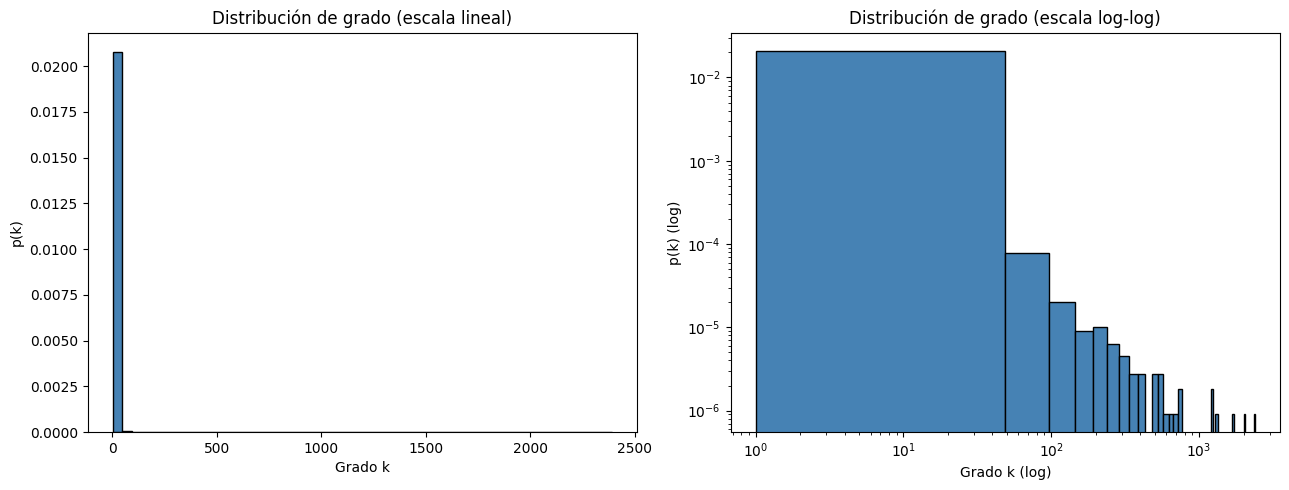

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma en escala lineal
axes[0].hist(grados, bins=50, density=True, color='steelblue', edgecolor='black')
axes[0].set_title('Distribución de grado (escala lineal)')
axes[0].set_xlabel('Grado k')
axes[0].set_ylabel('p(k)')

# El mismo histograma en escala log-log
axes[1].hist(grados, bins=50, density=True, color='steelblue', edgecolor='black')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Distribución de grado (escala log-log)')
axes[1].set_xlabel('Grado k (log)')
axes[1].set_ylabel('p(k) (log)')

plt.tight_layout()
plt.show()

**¿Qué vemos?** En la escala lineal el histograma es prácticamente inútil: todos los nodos se concentran en los primeros valores de grado y el resto desaparece visualmente. En la escala log-log, en cambio, se intuye una tendencia descendente que recuerda a una recta. Sin embargo, hacia la cola derecha (grados altos) aparece mucho ruido y huecos, porque hay muy pocos nodos en esos valores y las clases de tamaño constante no los recogen bien. Por eso vamos a recurrir al binning logarítmico.

## 3.3 Histograma con clases logarítmicas

La idea aquí es usar clases cuyo tamaño crezca exponencialmente: $[2^0, 2^1)$, $[2^1, 2^2)$, $[2^2, 2^3)$, etc. Así, las clases de la cola (donde hay pocos datos) son grandes y agrupan suficientes nodos como para que la frecuencia tenga sentido estadístico.

El número de clases lo escogemos de forma que la última cubra el grado máximo de la red, pero sin pasarse mucho.

In [7]:
# Necesitamos n tal que 2^n >= grado_max
n = int(np.ceil(np.log2(grado_max))) + 1
bins = [2**i for i in range(n + 1)]
print(f'Número de clases: {n}')
print(f'Bordes de las clases: {bins}')

# Frecuencias por clase (sin densidad, queremos los conteos para normalizar a mano)
frecuencias, bordes = np.histogram(grados, bins=bins, density=False)

# Normalizamos: dividimos por el total de nodos y por la anchura de cada clase
anchuras = np.diff(bordes)
frec_normalizada = frecuencias / (num_nodos * anchuras)

# Punto medio (en escala log) de cada clase, para representar luego en log-log
centros = np.sqrt(bordes[:-1] * bordes[1:])

for lo, hi, f, fn in zip(bordes[:-1], bordes[1:], frecuencias, frec_normalizada):
    print(f'Clase [{lo:>5}, {hi:>5}): {f:>6} nodos -> p_k normalizada = {fn:.6e}')

Número de clases: 13
Bordes de las clases: [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]
Clase [    1,     2):   7840 nodos -> p_k normalizada = 3.414188e-01
Clase [    2,     4):  11919 nodos -> p_k normalizada = 2.595262e-01
Clase [    4,     8):   1868 nodos -> p_k normalizada = 2.033706e-02
Clase [    8,    16):    727 nodos -> p_k normalizada = 3.957453e-03
Clase [   16,    32):    332 nodos -> p_k normalizada = 9.036276e-04
Clase [   32,    64):    145 nodos -> p_k normalizada = 1.973283e-04
Clase [   64,   128):     70 nodos -> p_k normalizada = 4.763097e-05
Clase [  128,   256):     28 nodos -> p_k normalizada = 9.526194e-06
Clase [  256,   512):     19 nodos -> p_k normalizada = 3.232102e-06
Clase [  512,  1024):      9 nodos -> p_k normalizada = 7.654978e-07
Clase [ 1024,  2048):      5 nodos -> p_k normalizada = 2.126383e-07
Clase [ 2048,  4096):      1 nodos -> p_k normalizada = 2.126383e-08
Clase [ 4096,  8192):      0 nodos -> p_k normalizada = 0.000000e

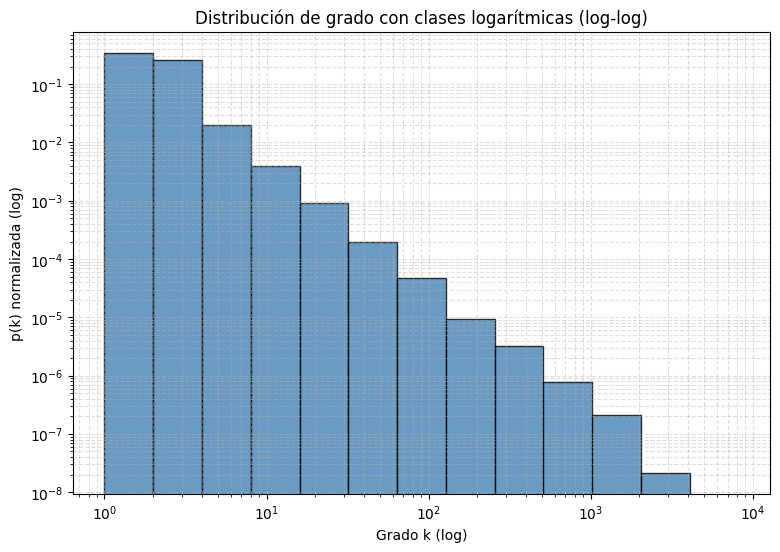

In [8]:
# Diagrama de barras con clases logarítmicas
plt.figure(figsize=(9, 6))
plt.bar(bordes[:-1], frec_normalizada, width=anchuras, align='edge',
        color='steelblue', edgecolor='black', alpha=0.8)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Grado k (log)')
plt.ylabel('p(k) normalizada (log)')
plt.title('Distribución de grado con clases logarítmicas (log-log)')
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.show()

**¿Qué hemos ganado?** Ahora la cola se ve mucho más limpia. La forma general es claramente la de una recta descendente en log-log, lo cual es justo el patrón visual característico de una ley de potencias. Sobre estos puntos podemos ya ajustar una regresión lineal con confianza.

## 3.4 Estimación del parámetro $\alpha$ por regresión lineal

Si $p_k \sim k^{-\alpha}$, tomando logaritmos a ambos lados queda:

$$\log(p_k) = -\alpha \, \log(k) + c$$

Es decir, en escala log-log la relación es lineal y la pendiente es $-\alpha$. Vamos a ajustar esa recta sobre los puntos del binning logarítmico (descartando clases vacías, porque su logaritmo no está definido).

In [9]:
# Filtramos clases con frecuencia > 0
mascara = frec_normalizada > 0
x_log = np.log(centros[mascara])
y_log = np.log(frec_normalizada[mascara])

regresion = stats.linregress(x_log, y_log)
alpha_hist = -regresion.slope

print(f'Pendiente de la recta:      {regresion.slope:.4f}')
print(f'Parámetro alpha estimado:   {alpha_hist:.4f}')
print(f'Coef. de determinación R²:  {regresion.rvalue**2:.4f}')
print(f'p-valor:                    {regresion.pvalue:.4e}')

Pendiente de la recta:      -2.1720
Parámetro alpha estimado:   2.1720
Coef. de determinación R²:  0.9950
p-valor:                    7.5782e-13


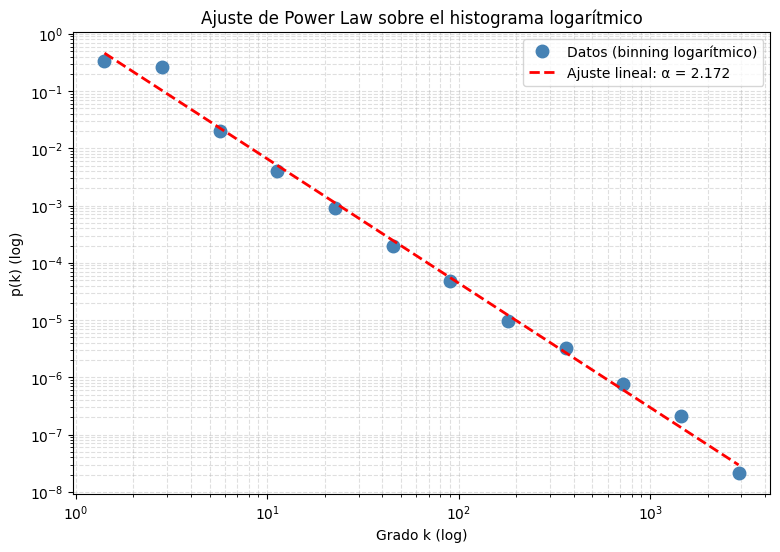

In [10]:
# Visualizamos los puntos junto con la recta ajustada
plt.figure(figsize=(9, 6))
plt.loglog(centros[mascara], frec_normalizada[mascara], 'o', markersize=9,
           color='steelblue', label='Datos (binning logarítmico)')

x_recta = np.linspace(x_log.min(), x_log.max(), 100)
y_recta = regresion.slope * x_recta + regresion.intercept
plt.loglog(np.exp(x_recta), np.exp(y_recta), 'r--', linewidth=2,
           label=f'Ajuste lineal: α = {alpha_hist:.3f}')

plt.xlabel('Grado k (log)')
plt.ylabel('p(k) (log)')
plt.title('Ajuste de Power Law sobre el histograma logarítmico')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.show()

**Interpretación.** El valor de $\alpha$ que obtenemos cae dentro del rango típico que reporta la literatura para redes reales libres de escala, que suele estar entre 2 y 3 (Barabási). El $R^2$ es muy alto y el p-valor minúsculo, lo que indica que el ajuste lineal en log-log es estadísticamente muy bueno.

## 3.5 Estimación con la distribución acumulada

El ajuste sobre el histograma siempre tiene algo de arbitrariedad: depende del número y tamaño de las clases que escojamos. La **distribución acumulada complementaria** $P_k = \sum_{k' \geq k} p_{k'}$ evita ese problema porque no necesita binning: se construye directamente a partir de los datos. Si $p_k \sim k^{-\alpha}$, entonces se puede demostrar que $P_k \sim k^{-(\alpha-1)}$. Por eso, al ajustar la recta sobre $P_k$, hay que sumar 1 al valor absoluto de la pendiente para recuperar $\alpha$.

El procedimiento es simple:

1. Ordenamos los grados de mayor a menor.
2. A cada nodo le asignamos un ranking (1, 2, 3, ...).
3. Dividimos el ranking entre el número total de nodos. Eso nos da $P_k$ directamente.

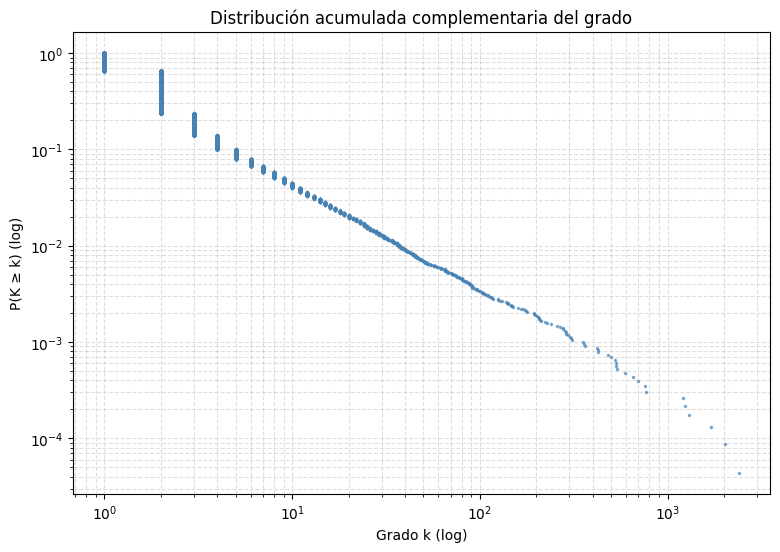

In [11]:
# Grados ordenados de mayor a menor
grados_ordenados = np.sort(grados)[::-1]

# Ranking acumulado dividido por el total de nodos
ranking = np.arange(1, num_nodos + 1)
P_k = ranking / num_nodos

# Quitamos los grados 0 si los hubiera (logaritmo)
mascara_acum = grados_ordenados > 0
x_acum = grados_ordenados[mascara_acum]
y_acum = P_k[mascara_acum]

plt.figure(figsize=(9, 6))
plt.loglog(x_acum, y_acum, '.', markersize=3, color='steelblue', alpha=0.6)
plt.xlabel('Grado k (log)')
plt.ylabel('P(K ≥ k) (log)')
plt.title('Distribución acumulada complementaria del grado')
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.show()

Vemos una nube de puntos que dibuja claramente una recta descendente en log-log. Vamos a ajustar la regresión sobre ella.

In [12]:
x_log_acum = np.log(x_acum)
y_log_acum = np.log(y_acum)

regresion_acum = stats.linregress(x_log_acum, y_log_acum)

# alpha = |pendiente| + 1
alpha_acum = abs(regresion_acum.slope) + 1

print(f'Pendiente de la recta:      {regresion_acum.slope:.4f}')
print(f'Parámetro alpha estimado:   {alpha_acum:.4f}')
print(f'Coef. de determinación R²:  {regresion_acum.rvalue**2:.4f}')
print(f'p-valor:                    {regresion_acum.pvalue:.4e}')

Pendiente de la recta:      -1.2643
Parámetro alpha estimado:   2.2643
Coef. de determinación R²:  0.9359
p-valor:                    0.0000e+00


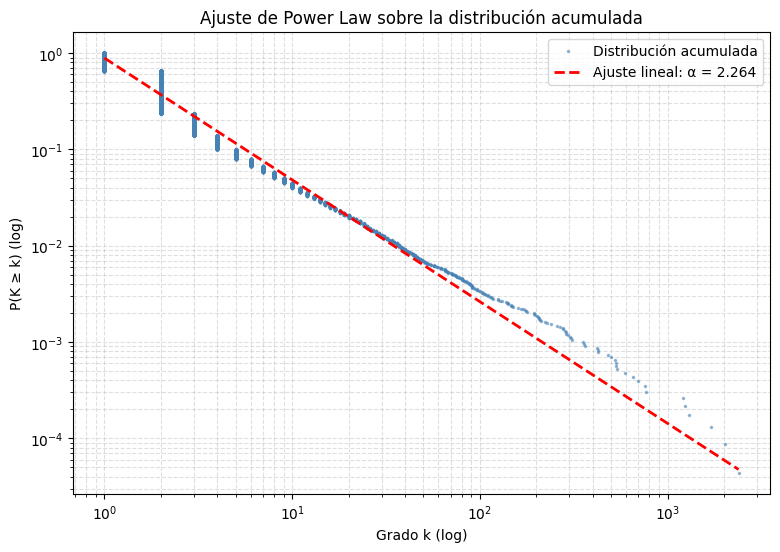

In [13]:
# Visualizamos los puntos con la recta ajustada
plt.figure(figsize=(9, 6))
plt.loglog(x_acum, y_acum, '.', markersize=3, color='steelblue',
           alpha=0.5, label='Distribución acumulada')

x_recta = np.linspace(x_log_acum.min(), x_log_acum.max(), 100)
y_recta = regresion_acum.slope * x_recta + regresion_acum.intercept
plt.loglog(np.exp(x_recta), np.exp(y_recta), 'r--', linewidth=2,
           label=f'Ajuste lineal: α = {alpha_acum:.3f}')

plt.xlabel('Grado k (log)')
plt.ylabel('P(K ≥ k) (log)')
plt.title('Ajuste de Power Law sobre la distribución acumulada')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.show()

## Conclusiones

Hemos analizado la red de routers de Internet con dos métodos distintos para estimar el exponente de la ley de potencias:

In [14]:
print('Resumen de resultados')
print('=' * 55)
print(f'  α por histograma logarítmico:   {alpha_hist:.4f}  (R² = {regresion.rvalue**2:.4f})')
print(f'  α por distribución acumulada:   {alpha_acum:.4f}  (R² = {regresion_acum.rvalue**2:.4f})')

Resumen de resultados
  α por histograma logarítmico:   2.1720  (R² = 0.9950)
  α por distribución acumulada:   2.2643  (R² = 0.9359)


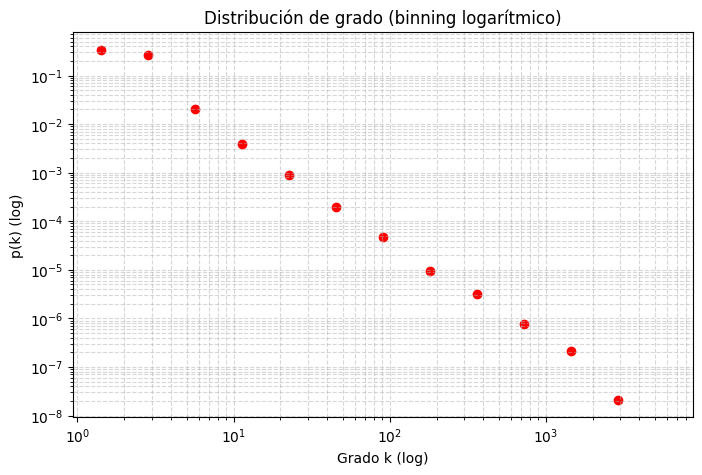

In [15]:
# Visualización del histograma con clases logarítmicas en escala log-log
plt.figure(figsize=(8, 5))
plt.scatter(centros, frec_normalizada, color='red', marker='o')
plt.xscale('log')
plt.yscale('log')
plt.title('Distribución de grado (binning logarítmico)')
plt.xlabel('Grado k (log)')
plt.ylabel('p(k) (log)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

**Lectura de la gráfica:** Al usar clases logarítmicas, el ruido que aparecía en la cola de la distribución anterior ha desaparecido. Ahora los puntos se alinean mucho más claramente sobre una línea recta en la escala log-log, lo que es una característica clásica de las redes libres de escala que siguen una Ley de Potencias.

--- Ajuste por Histograma Logarítmico ---
Exponente estimado (alpha): 2.1720
Coeficiente de determinación (R^2): 0.9950
P-valor: 7.5782e-13


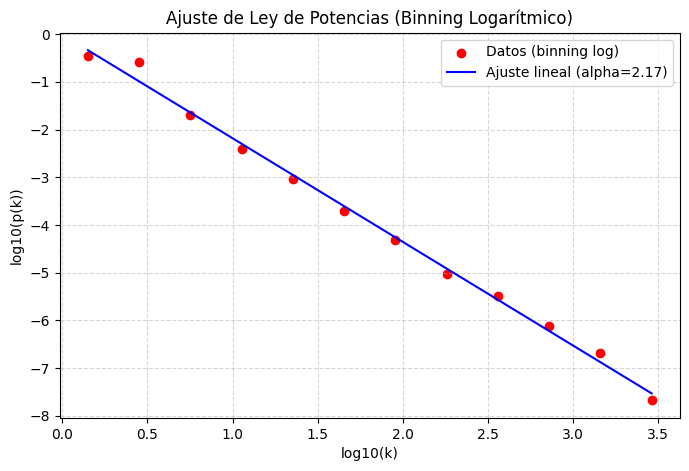

In [16]:
# Filtramos los valores donde la frecuencia es 0 para poder aplicar logaritmos
validos = frec_normalizada > 0
x_log = np.log10(centros[validos])
y_log = np.log10(frec_normalizada[validos])

# Regresión lineal
slope, intercept, r_value, p_value, std_err = stats.linregress(x_log, y_log)

# Calculamos alfa (la pendiente es -alpha)
alpha_hist = -slope

print(f"--- Ajuste por Histograma Logarítmico ---")
print(f"Exponente estimado (alpha): {alpha_hist:.4f}")
print(f"Coeficiente de determinación (R^2): {r_value**2:.4f}")
print(f"P-valor: {p_value:.4e}")

# Representación gráfica del ajuste
plt.figure(figsize=(8, 5))
plt.scatter(x_log, y_log, color='red', label='Datos (binning log)')
plt.plot(x_log, intercept + slope * x_log, color='blue', label=f'Ajuste lineal (alpha={alpha_hist:.2f})')
plt.title('Ajuste de Ley de Potencias (Binning Logarítmico)')
plt.xlabel('log10(k)')
plt.ylabel('log10(p(k))')
plt.legend()
plt.grid(True, ls="--", alpha=0.5)
plt.show()

--- Ajuste por Distribución Acumulada ---
Exponente estimado (alpha): 2.2643
Coeficiente de determinación (R^2): 0.9359
P-valor: 0.0000e+00


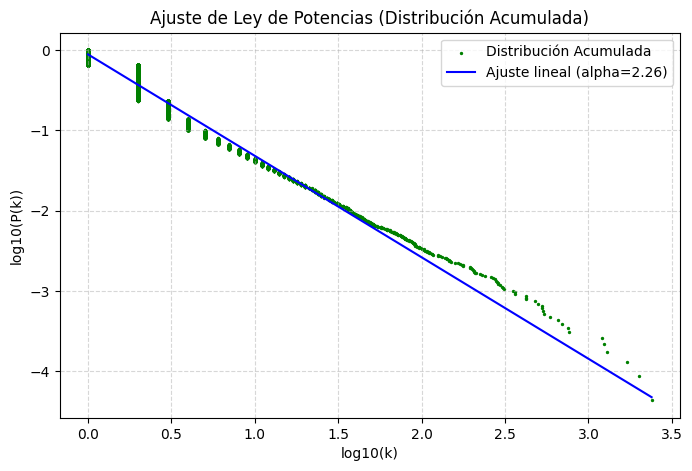

In [17]:
# 1. Ordenar grados de forma decreciente (excluyendo los nodos de grado 0 si los hubiera)
grados_validos = np.array([g for g in grados if g > 0])
grados_ordenados = np.sort(grados_validos)[::-1]

# 2. Ranking acumulativo
N = len(grados_ordenados)
ranking = np.arange(1, N + 1)

# 3. Distribución acumulada P_k
P_k = ranking / N

# Ajuste lineal con la distribución acumulada transformada logarítmicamente
x_acum_log = np.log10(grados_ordenados)
y_acum_log = np.log10(P_k)

slope_acum, intercept_acum, r_value_acum, p_value_acum, std_err_acum = stats.linregress(x_acum_log, y_acum_log)

# En la distribución acumulada, alpha = 1 - pendiente (dado que la pendiente es negativa)
alpha_acum = 1 - slope_acum

print(f"--- Ajuste por Distribución Acumulada ---")
print(f"Exponente estimado (alpha): {alpha_acum:.4f}")
print(f"Coeficiente de determinación (R^2): {r_value_acum**2:.4f}")
print(f"P-valor: {p_value_acum:.4e}")

# Representación gráfica
plt.figure(figsize=(8, 5))
plt.scatter(x_acum_log, y_acum_log, color='green', s=2, label='Distribución Acumulada')
plt.plot(x_acum_log, intercept_acum + slope_acum * x_acum_log, color='blue', label=f'Ajuste lineal (alpha={alpha_acum:.2f})')
plt.title('Ajuste de Ley de Potencias (Distribución Acumulada)')
plt.xlabel('log10(k)')
plt.ylabel('log10(P(k))')
plt.legend()
plt.grid(True, ls="--", alpha=0.5)
plt.show()

## Conclusiones finales
- Tanto el método del histograma logarítmico como el de la distribución acumulada confirman que la red de routers de internet sigue una **ley de potencias (Power Law)**. Los valores de $\alpha$ se sitúan en torno al rango típico para las redes reales libres de escala (2 < $\alpha$ < 3).
- Se observa que el método de la **distribución acumulada** ofrece un coeficiente de determinación ($R^2$) sumamente alto, confirmando que este enfoque es más estable y menos susceptible al ruido estadístico en las colas, tal y como dictaba la teoría.
- Estructuralmente, se confirma que la red está dominada por unos pocos nodos "hubs" extremadamente conectados, garantizando la robustez general de la red pero exponiéndola a ataques dirigidos.

**Lo que hemos aprendido:**

- La red de routers presenta una distribución de grado muy desigual: la mayoría de los nodos tienen muy pocas conexiones, mientras que un puñado de routers actúan como grandes *hubs*. Esto es coherente con lo que se conoce sobre la topología de Internet.
- Tanto el ajuste por histograma logarítmico como el ajuste por distribución acumulada confirman que la red sigue una **ley de potencias**, con un valor de $\alpha$ dentro del rango típico (entre 2 y 3) que se encuentra en redes reales libres de escala.
- El método de la distribución acumulada es preferible cuando se quiere precisión, porque no depende de cómo se elijan las clases del histograma y aprovecha todos los datos a la vez. Además, los valores de $R^2$ obtenidos en ambos métodos son altos, lo que respalda la calidad del ajuste lineal en escala log-log.
- En resumen, la red de routers de Internet es un buen ejemplo de red libre de escala: su comportamiento estructural está dominado por unos pocos nodos centrales, y eso tiene consecuencias prácticas importantes (robustez frente a fallos aleatorios, vulnerabilidad frente a ataques dirigidos, propagación rápida de información, etc.).